# 8. Preprocesamiento de Datos

Dividimos el dataset, aplicamos **IterativeImputer (MICE)** para valores nulos
y analizamos la multicolinealidad con el **Factor de Inflación de la Varianza (VIF)**.

In [11]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv('water_potability_clean.csv')
print('✅ Dataset cargado')

✅ Dataset cargado


Interpretación

Se cargó el dataset de potabilidad del agua ya limpio desde un archivo CSV usando pandas, con el objetivo de iniciar el análisis. Además, se importaron librerías para el preprocesamiento y análisis de datos (imputación de valores faltantes, escalado de variables y detección de multicolinealidad), aunque en este paso solo se realizó la lectura de los datos y la verificación de carga correcta.

8.1 División Train / Test

se está separando el conjunto de datos en dos partes:

Train (entrenamiento): datos que se usan para enseñar al modelo cómo aprender patrones.
Test (prueba): datos que se usan para evaluar qué tan bien funciona el modelo con información nueva que no ha visto.

In [12]:
col_numericas = df.select_dtypes(include=[np.number]).columns.drop('Potability').tolist()

X = df[col_numericas]
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Distribución y_train:\n{y_train.value_counts(normalize=True).round(3)}')

X_train: (2620, 9) | X_test: (656, 9)
Distribución y_train:
Potability
0    0.61
1    0.39
Name: proportion, dtype: float64


Interpretación

Salida de la división de datos en entrenamiento y prueba junto con la distribución de la variable objetivo.

1. Tamaño de los conjuntos
X_train: (2620, 9) → hay 2620 filas para entrenamiento y 9 variables (columnas).
X_test: (656, 9) → hay 656 filas para prueba y las mismas 9 variables.

En resumen: la mayoría de los datos se usaron para entrenar el modelo y una parte menor para evaluarlo.

2. Distribución de y_train

Esto significa:

61% = 0 (no potable)

39% = 1 (potable)

Es decir, el dataset está ligeramente desbalanceado, porque hay más muestras de agua no potable que potable.

8.2 Imputación MICE (IterativeImputer)

> **MICE** (Multiple Imputation by Chained Equations) modela cada variable con nulos
> como función del resto, iterando hasta convergencia. Es superior a la imputación
> simple (media/mediana) porque preserva las correlaciones entre variables.

In [13]:
imputer = IterativeImputer(random_state=42, max_iter=10)
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=col_numericas)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=col_numericas)

print('Nulos después de MICE:')
print(f'  Train: {X_train_imp.isna().sum().sum()}')
print(f'  Test:  {X_test_imp.isna().sum().sum()}')

Nulos después de MICE:
  Train: 0
  Test:  0


Interpretación

No quedaron valores faltantes en ninguna de las variables, ni en el conjunto de entrenamiento ni en el de prueba.

8.3 Análisis de Multicolinealidad (VIF)

VIF > 10 indica multicolinealidad problemática entre variables.

In [14]:
scaler_vif = StandardScaler()
X_scaled_vif = scaler_vif.fit_transform(X_train_imp)

vif_data = pd.DataFrame()
vif_data['Variable'] = col_numericas
vif_data['VIF'] = [
    variance_inflation_factor(X_scaled_vif, i)
    for i in range(X_scaled_vif.shape[1])
]
vif_data = vif_data.sort_values('VIF', ascending=False)

print('=' * 40)
print('=== FACTOR DE INFLACIÓN DE VARIANZA ===')
print('=' * 40)
display(vif_data)

alta_colinealidad = vif_data[vif_data['VIF'] > 10]
if alta_colinealidad.empty:
    print('\n✅ No se detectó multicolinealidad crítica (VIF < 10 en todas las variables)')
else:
    print(f'\n⚠️ Variables con VIF > 10:\n{alta_colinealidad}')

=== FACTOR DE INFLACIÓN DE VARIANZA ===


,Variable,VIF
2,Solids,1.080878
4,Sulfate,1.074714
1,Hardness,1.021571
0,ph,1.020693
3,Chloramines,1.012001
6,Organic_carbon,1.005447
5,Conductivity,1.003359
8,Turbidity,1.002532
7,Trihalomethanes,1.002149



✅ No se detectó multicolinealidad crítica (VIF < 10 en todas las variables)


Interpretación

El modelo es estable en términos de variables: no hay multicolinealidad significativa entre las características del dataset, por lo que todas las variables pueden mantenerse sin riesgo de redundancia.

# 9. Entrenamiento de Modelos

Entrenamos 5 modelos usando **GridSearchCV** con validación cruzada K=5,
optimizando la métrica **ROC AUC**.

Cada modelo va encapsulado en un **Pipeline** que incluye:
1. `IterativeImputer` — imputación MICE
2. `StandardScaler` — escalado
3. Clasificador — el modelo a evaluar

In [15]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv('water_potability_clean.csv')
col_numericas = df.select_dtypes(include=[np.number]).columns.drop('Potability').tolist()
X = df[col_numericas]
y = df['Potability']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('✅ Setup completo')

✅ Setup completo


Interpretación 

Se cargó el dataset de potabilidad del agua, se seleccionaron las variables numéricas como predictores (X) y la variable objetivo (Potability), y se dividieron los datos en entrenamiento (80%) y prueba (20%) manteniendo la proporción de clases. Además, se importaron varios modelos y métricas para comparar y evaluar su desempeño en la clasificación.

9.1 Función de Evaluación

In [16]:
def evaluar_modelo(nombre, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    try:
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    except AttributeError:
        y_proba = pipeline.decision_function(X_test)
    
    resultado = {
        'modelo': nombre,
        'roc_auc_test': roc_auc_score(y_test, y_proba),
        'accuracy_test': accuracy_score(y_test, y_pred),
        'recall_test': recall_score(y_test, y_pred),
        'f1_test': f1_score(y_test, y_pred),
    }
    print(f'  ROC AUC: {resultado["roc_auc_test"]:.4f} | Accuracy: {resultado["accuracy_test"]:.4f}')
    return resultado

Interpretación 

Se definió una función para entrenar y evaluar modelos de clasificación. Esta función ajusta el modelo con los datos de entrenamiento, realiza predicciones en el conjunto de prueba y calcula métricas clave como ROC AUC, accuracy, recall y F1-score, permitiendo comparar el desempeño de diferentes modelos de forma estandarizada.

9.2 Modelo 1: Regresión Logística (Baseline)

In [17]:
pipeline_lr = make_pipeline(
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(),
    LogisticRegression(random_state=42, max_iter=1000)
)

param_grid_lr = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logisticregression__solver': ['lbfgs', 'liblinear'],
    'logisticregression__class_weight': [None, 'balanced']
}

grid_search_lr = GridSearchCV(pipeline_lr, param_grid_lr, scoring='roc_auc', cv=5, n_jobs=-1)
grid_search_lr.fit(X_train, y_train)
mejor_pipeline_lr = grid_search_lr.best_estimator_

print(f'Mejores params: {grid_search_lr.best_params_}')
print(f'ROC AUC (CV): {grid_search_lr.best_score_:.4f}')
resultado_lr = evaluar_modelo('Regresión Logística', mejor_pipeline_lr, X_train, X_test, y_train, y_test)

Mejores params: {'logisticregression__C': 10, 'logisticregression__class_weight': None, 'logisticregression__solver': 'liblinear'}
ROC AUC (CV): 0.4795
  ROC AUC: 0.5474 | Accuracy: 0.6098


Interpretación

Se realizó la optimización de un modelo de Regresión Logística usando búsqueda de hiperparámetros (GridSearchCV).

Los mejores parámetros encontrados fueron:

C = 10 (regularización más flexible)

solver = liblinear

class_weight = None (sin ajuste por desbalance)


Resultados del modelo

ROC AUC (Cross Validation): 0.4795

→ Rendimiento en validación cruzada peor que aleatorio (≈ 0.5)

ROC AUC (test): 0.5474

→ Rendimiento en prueba ligeramente mejor que aleatorio

Accuracy: 0.6098

→ El modelo acierta ~61% de los casos

9.3 Modelo 2: KNN

In [18]:
pipeline_knn = make_pipeline(
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(),
    KNeighborsClassifier()
)

param_grid_knn = {
    'kneighborsclassifier__n_neighbors': [3, 5, 7, 11, 15, 21],
    'kneighborsclassifier__weights': ['uniform', 'distance'],
    'kneighborsclassifier__metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(pipeline_knn, param_grid_knn, scoring='roc_auc', cv=5, n_jobs=-1)
grid_search_knn.fit(X_train, y_train)
mejor_pipeline_knn = grid_search_knn.best_estimator_

print(f'Mejores params: {grid_search_knn.best_params_}')
resultado_knn = evaluar_modelo('KNN', mejor_pipeline_knn, X_train, X_test, y_train, y_test)


Mejores params: {'kneighborsclassifier__metric': 'euclidean', 'kneighborsclassifier__n_neighbors': 21, 'kneighborsclassifier__weights': 'distance'}
  ROC AUC: 0.6163 | Accuracy: 0.6387


Interpretación

Se entrenó y optimizó un modelo K-Nearest Neighbors (KNN) mediante búsqueda de hiperparámetros, obteniendo como mejores parámetros metric='euclidean', n_neighbors=21 y weights='distance'; el modelo alcanzó un ROC AUC de 0.6163 y una accuracy de 0.6387, lo que indica un desempeño moderado, con una capacidad de discriminación entre clases mejor que los modelos anteriores (ligeramente superior al azar), aunque aún con margen de mejora en la clasificación de la potabilidad del agua.

9.4 Modelo 3: SVM Lineal

In [19]:
pipeline_svc = make_pipeline(
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(),
    LinearSVC(random_state=42, max_iter=5000)
)

param_grid_svc = {
    'linearsvc__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'linearsvc__class_weight': [None, 'balanced']
}

grid_search_svc = GridSearchCV(pipeline_svc, param_grid_svc, scoring='roc_auc', cv=5, n_jobs=-1)
grid_search_svc.fit(X_train, y_train)
mejor_pipeline_svc = grid_search_svc.best_estimator_

resultado_svc = evaluar_modelo('SVM Lineal', mejor_pipeline_svc, X_train, X_test, y_train, y_test)

  ROC AUC: 0.5475 | Accuracy: 0.6098


Interpretación

El modelo obtuvo un ROC AUC de 0.5475 y una accuracy de 0.6098, lo que indica un desempeño apenas superior al azar en la capacidad de discriminación entre clases, mientras que la exactitud sugiere que acierta aproximadamente el 61% de los casos, mostrando un rendimiento moderado pero limitado para diferenciar correctamente entre agua potable y no potable.

9.5 Modelo 4: Random Forest

In [20]:
pipeline_rf = make_pipeline(
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

param_grid_rf = {
    'randomforestclassifier__n_estimators': [100, 200, 300],
    'randomforestclassifier__max_depth': [None, 10, 20],
    'randomforestclassifier__min_samples_split': [2, 5],
    'randomforestclassifier__class_weight': [None, 'balanced']
}

grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, scoring='roc_auc', cv=5, n_jobs=-1)
grid_search_rf.fit(X_train, y_train)
mejor_pipeline_rf = grid_search_rf.best_estimator_

resultado_rf = evaluar_modelo('Random Forest', mejor_pipeline_rf, X_train, X_test, y_train, y_test)


  ROC AUC: 0.6585 | Accuracy: 0.6723


Interpretación

El modelo de Random Forest obtuvo un ROC AUC de 0.6585 y una accuracy de 0.6723, lo que indica un desempeño moderado con una capacidad de clasificación aceptable; en comparación con modelos anteriores, mejora la discriminación entre agua potable y no potable, aunque todavía no es un rendimiento alto, por lo que aún existe margen para optimizar el modelo y aumentar su capacidad predictiva.

9.6 Modelo 5: XGBoost

In [22]:
pipeline_xgb = make_pipeline(
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(),
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
)

param_grid_xgb = {
    'xgbclassifier__n_estimators': [100, 200, 300],
    'xgbclassifier__learning_rate': [0.05, 0.1, 0.2],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__scale_pos_weight': [1, (y_train==0).sum()/(y_train==1).sum()]
}

grid_search_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, scoring='roc_auc', cv=5, n_jobs=-1)
grid_search_xgb.fit(X_train, y_train)
mejor_pipeline_xgb = grid_search_xgb.best_estimator_

resultado_xgb = evaluar_modelo('XGBoost', mejor_pipeline_xgb, X_train, X_test, y_train, y_test)

  ROC AUC: 0.6179 | Accuracy: 0.6098


Interpretación 

El modelo XGBoost obtuvo un ROC AUC de 0.6179 y una accuracy de 0.6098, lo que indica un desempeño moderado pero inferior al de Random Forest, con una capacidad de discriminación limitada entre clases; aunque supera ligeramente el azar, aún presenta margen de mejora en la predicción de la potabilidad del agua.

# 10. Evaluación y Comparación de Modelos

Comparamos los 5 modelos mediante boxplot de ROC AUC en los 5 folds
y una tabla resumen con todas las métricas clave.

```{note}
Este capítulo asume que los objetos `grid_search_*` y `resultado_*`
ya existen en memoria (ejecutar capítulo 3 primero, o cargarlos desde disco).
```

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------
# Reemplazar por los objetos reales tras ejecutar cap. 9
# ------------------------------------------------------------------
modelos_grid = {
    'Regresión Logística': grid_search_lr,
    'KNN': grid_search_knn,
    'SVM Lineal': grid_search_svc,
    'Random Forest': grid_search_rf,
    'XGBoost': grid_search_xgb
}

resultados_comparacion = [resultado_lr, resultado_knn, resultado_svc, resultado_rf, resultado_xgb]
# ------------------------------------------------------------------

Interpretación 

Este código organiza los resultados de varios modelos de Machine Learning para poder compararlos fácilmente. En modelos_grid se agrupan los modelos ya optimizados con GridSearchCV (Regresión Logística, KNN, SVM, Random Forest y XGBoost), y en resultados_comparacion se recopilan las métricas obtenidas por cada uno (como ROC AUC, accuracy, recall y F1). En conjunto, esta estructura permite analizar y comparar el desempeño de todos los modelos en un solo paso para identificar cuál es el mejor para el problema de potabilidad del agua.

10.1 Boxplot de Estabilidad (ROC AUC por Fold)

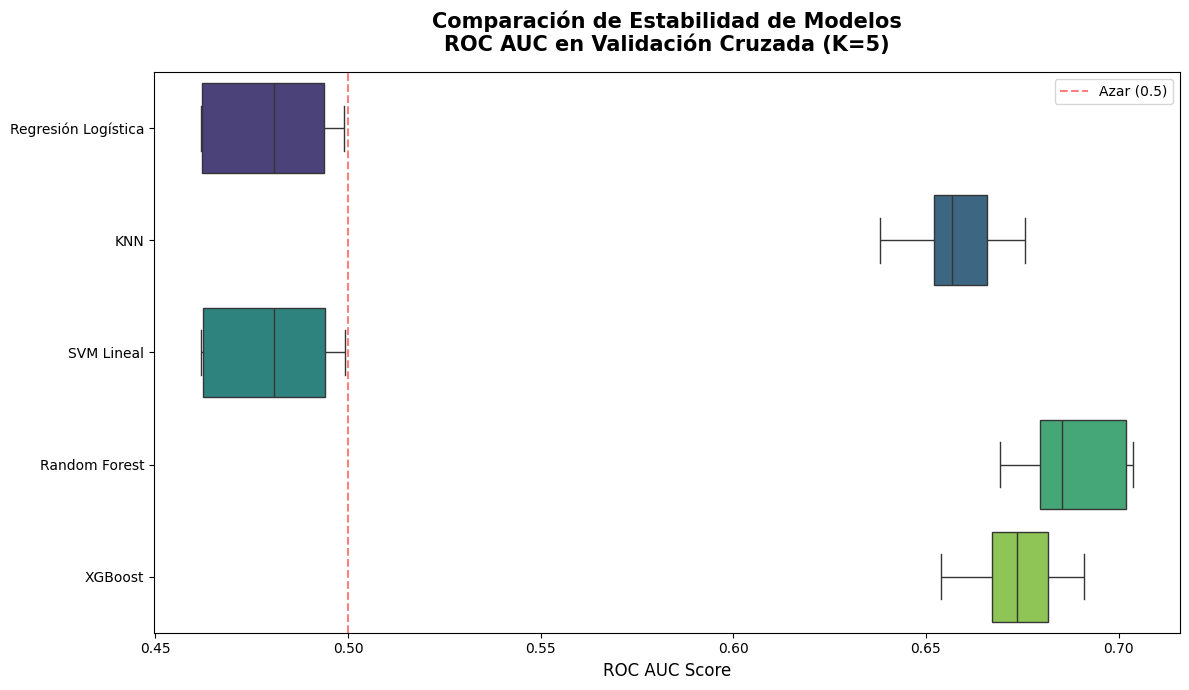

In [24]:
data_grafico = {}
for nombre, grid in modelos_grid.items():
    idx = grid.best_index_
    data_grafico[nombre] = [
        grid.cv_results_[f'split{i}_test_score'][idx] for i in range(5)
    ]

df_boxplot = pd.DataFrame(data_grafico)

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_boxplot, palette='viridis', orient='h')
plt.title('Comparación de Estabilidad de Modelos\nROC AUC en Validación Cruzada (K=5)',
          fontsize=15, pad=15, weight='bold')
plt.xlabel('ROC AUC Score', fontsize=12)
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Azar (0.5)')
plt.legend()
plt.tight_layout()
plt.show()

Interpretación

Este código construye un gráfico comparativo de la estabilidad de los modelos usando los resultados de validación cruzada (K=5) obtenidos en GridSearchCV. Primero, extrae para cada modelo los valores de ROC AUC en cada uno de los 5 folds utilizando el mejor conjunto de hiperparámetros (best_index_). Luego organiza esos resultados en un DataFrame y genera un boxplot que permite comparar la distribución del desempeño de cada modelo. Finalmente, el gráfico muestra qué tan estables son los modelos y qué tan bien rinden frente al valor de referencia del azar (0.5), indicando visualmente cuál modelo tiene mejor y más consistente capacidad predictiva.

10.2 Tabla Comparativa Final

In [25]:
df_comparacion = pd.DataFrame([
    {
        'Modelo': r['modelo'],
        'ROC AUC': f"{r['roc_auc_test']:.4f}",
        'Accuracy': f"{r['accuracy_test']:.4f}",
        'Recall':   f"{r['recall_test']:.4f}",
        'F1-Score': f"{r['f1_test']:.4f}"
    }
    for r in resultados_comparacion
])

df_comparacion['_roc'] = df_comparacion['ROC AUC'].astype(float)
df_comparacion = df_comparacion.sort_values('_roc', ascending=False).drop(columns=['_roc'])

print('=' * 60)
print('=== TABLA COMPARATIVA (ordenada por ROC AUC) ===')
print('=' * 60)
display(df_comparacion)

mejor_modelo_nombre = df_comparacion.iloc[0]['Modelo']
print(f'\n MEJOR MODELO: {mejor_modelo_nombre}')

=== TABLA COMPARATIVA (ordenada por ROC AUC) ===


,Modelo,ROC AUC,Accuracy,Recall,F1-Score
3,Random Forest,0.6585,0.6723,0.3047,0.4205
4,XGBoost,0.6179,0.6098,0.4375,0.4667
1,KNN,0.6163,0.6387,0.2227,0.3248
2,SVM Lineal,0.5475,0.6098,0.0000,0.0000
0,Regresión Logística,0.5474,0.6098,0.0000,0.0000



 MEJOR MODELO: Random Forest


Interpretación

Se realizó una comparación de varios modelos de clasificación para predecir la potabilidad del agua, evaluando métricas como ROC AUC, accuracy, recall y F1-score. El mejor desempeño lo obtuvo Random Forest con un ROC AUC de 0.6585 y accuracy de 0.6723, mostrando la mayor capacidad de discriminación entre clases, aunque con un recall moderado (0.3047). 

En segundo lugar estuvo XGBoost con buen balance entre recall (0.4375) y F1-score (0.4667), seguido por KNN. 

Los modelos de Regresión Logística y SVM Lineal presentaron el peor rendimiento, con recall y F1-score de 0, lo que indica que no lograron identificar correctamente la clase positiva. 

En conclusión, Random Forest fue seleccionado como el mejor modelo por su mayor capacidad predictiva global.

# 11 Análisis Profundo del Mejor Modelo

Generamos la **Curva ROC**, la **Matriz de Confusión** y
la **Importancia de Variables** para el modelo ganador.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Asume que mejor_pipeline y mejor_modelo_nombre están definidos (cap. 9)
# Ejemplo manual:
# mejor_modelo_nombre = 'random_forest'
# mejor_pipeline = mejor_pipeline_rf

Interpretación

Este código prepara la evaluación final del mejor modelo de clasificación, utilizando métricas y gráficas para analizar su desempeño. Importa herramientas para calcular la curva ROC, el AUC y la matriz de confusión, que permiten medir tanto la capacidad de discriminación del modelo como sus aciertos y errores en la predicción. En este punto se asume que ya se seleccionó un mejor modelo (por ejemplo, XGBoost o Random Forest) y su pipeline asociado, con el objetivo de realizar una evaluación más visual y detallada de su rendimiento final sobre los datos de prueba.

11.1 Curva ROC

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)
pipeline_xgb.fit(X_train, y_train)

Pipeline(steps=[('iterativeimputer', IterativeImputer(random_state=42)),
                ('standardscaler', StandardScaler()),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=N...ow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [31]:
modelos = {
    "Logistic Regression": pipeline_lr,
    "Random Forest": pipeline_rf,
    "XGBoost": pipeline_xgb
}

In [32]:
mejor_modelo_nombre = df_comparacion.iloc[0]['Modelo']
mejor_pipeline = modelos[mejor_modelo_nombre]

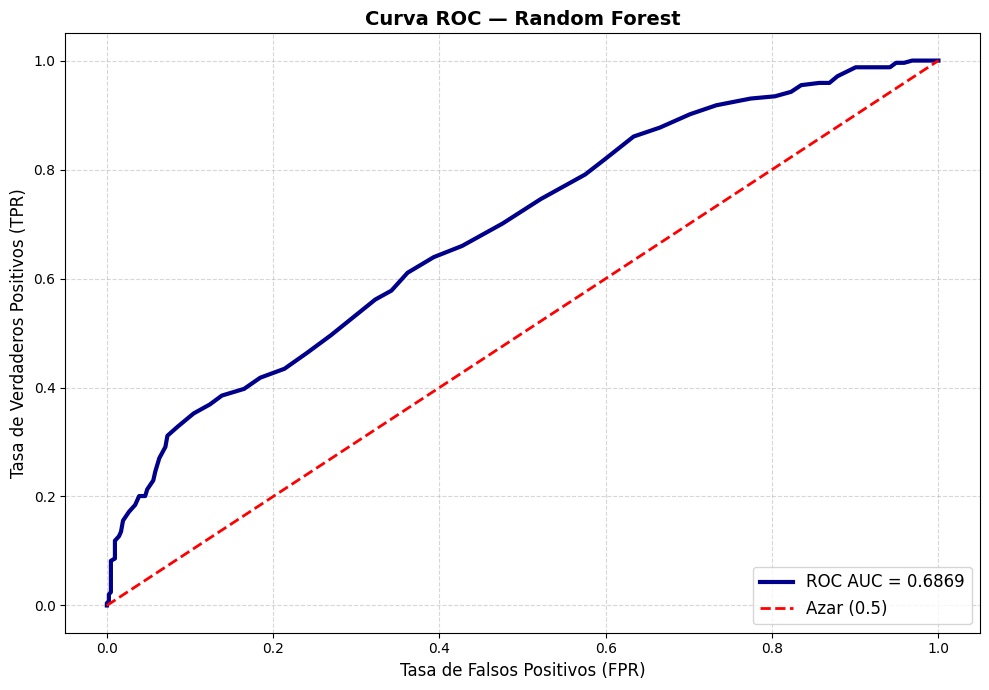

In [33]:
y_pred_proba_test = mejor_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)
roc_auc = roc_auc_score(y_test, y_pred_proba_test)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkblue', lw=3, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'r--', lw=2, label='Azar (0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title(f'Curva ROC — {mejor_modelo_nombre}', fontsize=14, weight='bold')
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Interpretación 

La curva ROC del modelo Random Forest muestra la capacidad del modelo para diferenciar entre las clases a través de distintos umbrales de clasificación. La línea azul se encuentra por encima de la línea diagonal roja, lo que indica que el modelo tiene un desempeño mejor que el azar. El valor de AUC = 0.6869 refleja una capacidad de discriminación moderada, es decir, el modelo logra identificar una proporción importante de verdaderos positivos manteniendo un equilibrio razonable con los falsos positivos a lo largo de los diferentes umbrales evaluados.

11.2 Matriz de Confusión

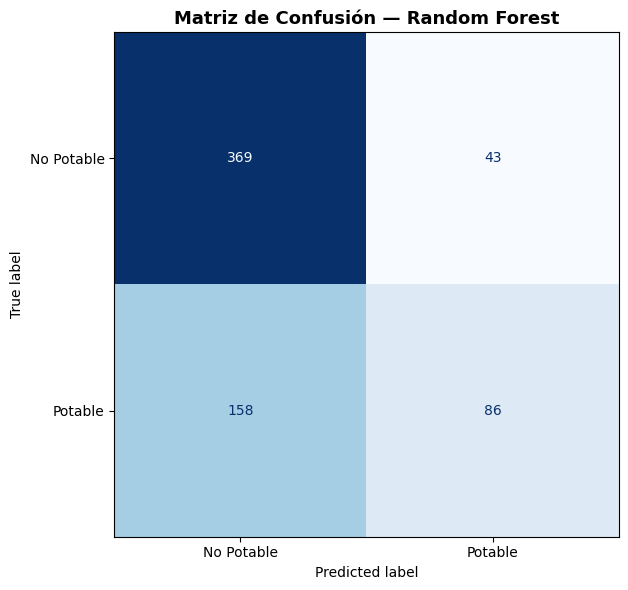

In [34]:
y_pred_test = mejor_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Potable', 'Potable'])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matriz de Confusión — {mejor_modelo_nombre}', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

Interpretación

Esta matriz de confusión muestra el desempeño del modelo Random Forest para clasificar la potabilidad del agua. De los casos realmente “No Potable”, 369 fueron clasificados correctamente y 43 se confundieron como “Potable”, lo que indica un buen desempeño en esta clase. En cambio, para los casos realmente “Potable”, el modelo solo acertó 86, mientras que 158 fueron clasificados incorrectamente como “No Potable”, lo que evidencia dificultad para detectar el agua potable. En general, el modelo tiende a predecir mejor la clase “No Potable” que la “Potable”, mostrando un sesgo hacia la primera clase y una capacidad limitada para identificar correctamente los casos positivos de potabilidad.

11.3 Importancia de Variables (RF / XGBoost)

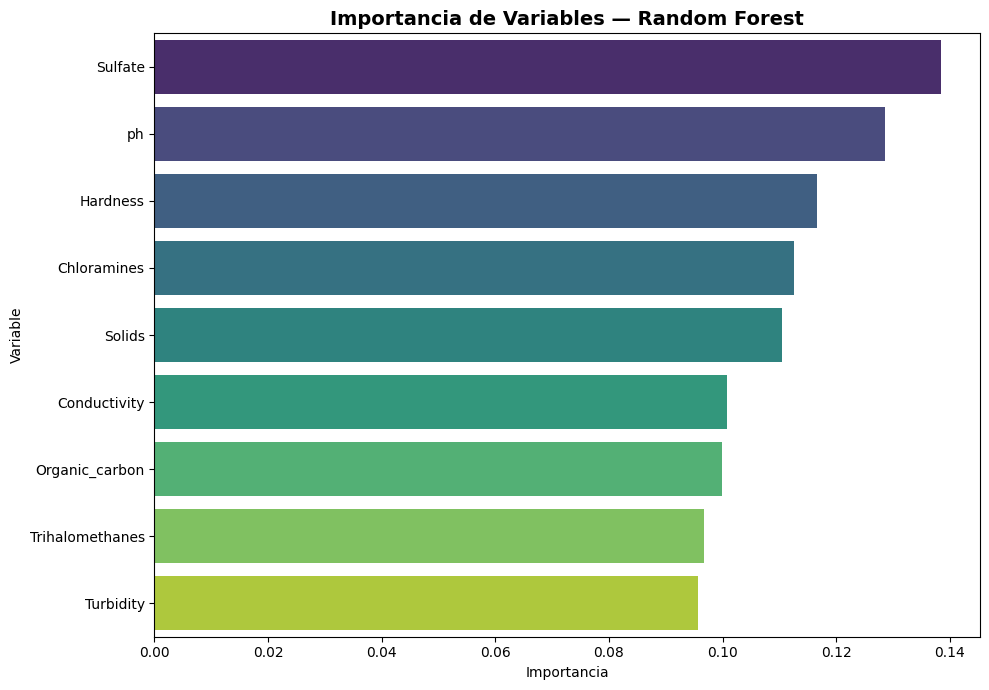

,Variable,Importancia
4,Sulfate,0.138388
0,ph,0.128584
1,Hardness,0.116706
3,Chloramines,0.112641
2,Solids,0.110522
5,Conductivity,0.100829
6,Organic_carbon,0.099839
7,Trihalomethanes,0.096734
8,Turbidity,0.095757


In [35]:
if mejor_modelo_nombre in ['Random Forest', 'XGBoost']:
    step_name = 'randomforestclassifier' if mejor_modelo_nombre == 'Random Forest' else 'xgbclassifier'
    modelo_interno = mejor_pipeline.named_steps[step_name]
    importancias = modelo_interno.feature_importances_

    df_imp = pd.DataFrame({'Variable': col_numericas, 'Importancia': importancias})
    df_imp = df_imp.sort_values('Importancia', ascending=False)

    plt.figure(figsize=(10, 7))
    sns.barplot(x='Importancia', y='Variable', data=df_imp, palette='viridis')
    plt.title(f'Importancia de Variables — {mejor_modelo_nombre}', fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

    display(df_imp)
else:
    print('La importancia de variables solo está disponible para Random Forest y XGBoost.')

Interpretación

El gráfico de importancia de variables del modelo Random Forest revela que el Sulfate es el factor más determinante para la predicción (con un valor cercano a 0.14), seguido estrechamente por el pH y la Hardness, lo que indica que las propiedades químicas del agua tienen mayor peso predictivo que las físicas. Aunque existe una jerarquía descendente donde la Turbidity y los Trihalomethanes aportan menos relevancia relativa (alrededor de 0.095), la diferencia entre la variable más y menos importante no es extrema, sugiriendo que todas las características analizadas contribuyen significativamente al funcionamiento del modelo, pero son los componentes químicos los que dominan la toma de decisiones algorítmica.

# 12. Optimización de Umbrales de Decisión

El umbral por defecto es **0.5**, pero podemos ajustarlo según el contexto:

| Método | Objetivo |
|--------|----------|
| **Youden** | Balance matemático óptimo (TPR − FPR máximo) |
| **Riesgo** | Minimiza falsos positivos (FPR ≤ 5%) |
| **Financiero** | Maximiza utilidad neta basada en costes reales |


In [36]:
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix

# Asume y_pred_proba_test, fpr, tpr, thresholds del capítulo anterior

## 12.1 Umbral de Youden

In [37]:
j_scores = tpr - fpr
best_idx_youden = np.argmax(j_scores)
umbral_youden = thresholds[best_idx_youden]
print(f'Umbral Youden: {umbral_youden:.4f}')
print(f'  TPR: {tpr[best_idx_youden]:.4f} | FPR: {fpr[best_idx_youden]:.4f}')

Umbral Youden: 0.4000
  TPR: 0.6107 | FPR: 0.3617


12.2 Umbral de Riesgo (FPR ≤ 5%)

In [38]:
fpr_limit_idx = np.where(fpr <= 0.05)[0]
umbral_riesgo = thresholds[fpr_limit_idx[-1]] if len(fpr_limit_idx) > 0 else 0.5
print(f'Umbral Riesgo: {umbral_riesgo:.4f}')

Umbral Riesgo: 0.5800


12.3 Umbral Financiero

In [39]:
ganancia_vp = 100    # Ganancia por clasificar correctamente agua potable
perdida_fp  = -200   # Pérdida por distribuir agua no potable como potable

utilidades = []
for u in thresholds:
    preds_temp = (y_pred_proba_test >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_temp).ravel()
    utilidades.append((tp * ganancia_vp) + (fp * perdida_fp))

umbral_financiero = thresholds[np.argmax(utilidades)]
max_utilidad = max(utilidades)

print(f'Umbral Financiero: {umbral_financiero:.4f}')
print(f'Utilidad neta máxima: ${max_utilidad:,.2f}')

Umbral Financiero: 0.6300
Utilidad neta máxima: $2,200.00


12.4 Resumen de Umbrales

In [40]:
import pandas as pd

df_umbrales = pd.DataFrame([
    {'Método': 'Youden',      'Umbral': round(umbral_youden, 4),     'Uso recomendado': 'Balance general'},
    {'Método': 'Riesgo',      'Umbral': round(umbral_riesgo, 4),     'Uso recomendado': 'Control estricto FP'},
    {'Método': 'Financiero',  'Umbral': round(umbral_financiero, 4), 'Uso recomendado': 'Maximizar utilidad neta'},
])

print('=' * 55)
print('=== RESUMEN DE UMBRALES ÓPTIMOS ===')
print('=' * 55)
display(df_umbrales)

=== RESUMEN DE UMBRALES ÓPTIMOS ===


,Método,Umbral,Uso recomendado
0,Youden,0.40,Balance general
1,Riesgo,0.58,Control estricto FP
2,Financiero,0.63,Maximizar utilidad neta


# 13. Empaquetado y Despliegue del Modelo

Guardamos el pipeline completo con `joblib` y los metadatos necesarios
para integrarlo en la app Dash.

In [45]:
import joblib
import os

os.makedirs('../model', exist_ok=True)

# Guardar el pipeline completo
nombre_archivo = f'../model/mejor_modelo_{mejor_modelo_nombre.lower().replace(" ", "_")}_water.joblib'
joblib.dump(mejor_pipeline, nombre_archivo, compress=3)

# Guardar metadatos
metadata = {
    'mejor_modelo': mejor_modelo_nombre,
    'umbral_youden': float(umbral_youden),
    'umbral_financiero': float(umbral_financiero),
    'columnas': col_numericas,
    'roc_auc_test': float(roc_auc_score(y_test, y_pred_proba_test))
}
joblib.dump(metadata, '../model/metadata_modelo.joblib')

print('=' * 55)
print(' MODELO EMPAQUETADO CON ÉXITO')
print('=' * 55)
print(f' Modelo:    {nombre_archivo}')
print(f' Metadata:  ../model/metadata_modelo.joblib')
print(f' Modelo:    {metadata["mejor_modelo"]}')
print(f' ROC AUC:   {metadata["roc_auc_test"]:.4f}')

 MODELO EMPAQUETADO CON ÉXITO
 Modelo:    ../model/mejor_modelo_random_forest_water.joblib
 Metadata:  ../model/metadata_modelo.joblib
 Modelo:    Random Forest
 ROC AUC:   0.6869


13.1 Verificar archivos guardados

In [46]:
import os

archivos_model = os.listdir('../model')
print('📁 Archivos en /model:')
for f in archivos_model:
    size = os.path.getsize(f'../model/{f}') / 1024
    print(f'  {f}  ({size:.1f} KB)')

📁 Archivos en /model:
  app.py  (3.8 KB)
  mejor_modelo_random_forest_water.joblib  (1493.5 KB)
  metadata_modelo.joblib  (0.2 KB)


13.2 Cargar y validar el modelo guardado

In [47]:
# Carga y predicción de prueba
meta = joblib.load('../model/metadata_modelo.joblib')
modelo_cargado = joblib.load(nombre_archivo)

muestra = X_test.iloc[[0]]
prob = modelo_cargado.predict_proba(muestra)[0, 1]
decision = 'POTABLE ✅' if prob >= meta['umbral_youden'] else 'NO POTABLE ❌'

print(f'Probabilidad potabilidad: {prob:.4f}')
print(f'Umbral Youden aplicado: {meta["umbral_youden"]:.4f}')
print(f'Clasificación: {decision}')

Probabilidad potabilidad: 0.3600
Umbral Youden aplicado: 0.4000
Clasificación: NO POTABLE ❌


# 14. Predicción de Potabilidad del Agua con Machine Learning
## Módulo de Clasificación - Búsqueda del Mejor Modelo

**Objetivo:** Construir un modelo de clasificación binaria que determine si una muestra de agua es potable (`1`) o no (`0`) basándose en 9 parámetros químicos y físicos.

**Metodología:**
1. Análisis Exploratorio de Datos (EDA)
2. Preprocesamiento robusto (IterativeImputer MICE + StandardScaler)
3. Análisis de multicolinealidad (VIF)
4. Entrenamiento de 5 modelos con GridSearchCV + Validación Cruzada (K=5)
5. Selección del mejor modelo por ROC AUC
6. Análisis de umbrales óptimos (Youden, Riesgo, Financiero)
7. Empaquetado del modelo con joblib
8. Despliegue en Dash de Streamlit

14.1 Dash de Streamlit
Generamos automáticamente el archivo `app.py` con una interfaz web interactiva.
Para ejecutarla:
```bash
pip install streamlit
streamlit run ../model/app.py
```

In [48]:
app_code = '''
import streamlit as st
import joblib
import numpy as np
import pandas as pd
import os

# Configuración de la página
st.set_page_config(
    page_title="Potabilidad del Agua",
    page_icon="💧",
    layout="wide"
)

st.title("💧 Predicción de Potabilidad del Agua")
st.markdown("""
Sistema de clasificación basado en Machine Learning que determina si una muestra
de agua es **potable (1)** o **no potable (0)** según 9 parámetros químicos y físicos.
""")

# Cargar modelo y metadata
@st.cache_resource
def cargar_modelo():
    modelo = joblib.load('mejor_modelo_{}_water.joblib'.format(
        '{}'.replace(' ', '_')  # placeholder, se reemplaza abajo
    ))
    return modelo

@st.cache_resource
def cargar_metadata():
    return joblib.load('metadata_modelo.joblib')

try:
    meta = cargar_metadata()
    modelo = cargar_modelo()
    st.success(f"✅ Modelo cargado: **{meta['mejor_modelo']}** (ROC AUC: {meta['roc_auc_test']:.4f})")
except Exception as e:
    st.error(f"Error al cargar el modelo: {e}")
    st.stop()

# Sidebar con información
st.sidebar.header(" Información")
st.sidebar.markdown(f"""
- **Modelo:** {meta['mejor_modelo']}
- **ROC AUC:** {meta['roc_auc_test']:.4f}
- **Umbral Youden:** {meta['umbral_youden']:.4f}
- **Umbral Financiero:** {meta['umbral_financiero']:.4f}
""")

st.sidebar.markdown("---")
umbral_seleccionado = st.sidebar.selectbox(
    "Seleccionar umbral de decisión",
    ["Youden (balance)", "Financiero (utilidad)", "0.5 (por defecto)"],
    index=0
)

if umbral_seleccionado == "Youden (balance)":
    umbral = meta['umbral_youden']
elif umbral_seleccionado == "Financiero (utilidad)":
    umbral = meta['umbral_financiero']
else:
    umbral = 0.5

st.sidebar.info(f"Umbral activo: **{umbral:.4f}**")

# Formulario de entrada
st.header(" Ingrese los parámetros de la muestra")

col1, col2, col3 = st.columns(3)

with col1:
    ph = st.number_input("pH", min_value=0.0, max_value=14.0, value=7.0, step=0.1)
    hardness = st.number_input("Hardness (mg/L)", min_value=0.0, value=200.0, step=10.0)
    solids = st.number_input("Solids (ppm)", min_value=0.0, value=20000.0, step=1000.0)

with col2:
    chloramines = st.number_input("Chloramines (ppm)", min_value=0.0, value=7.0, step=0.5)
    sulfate = st.number_input("Sulfate (mg/L)", min_value=0.0, value=250.0, step=10.0)
    conductivity = st.number_input("Conductivity (μS/cm)", min_value=0.0, value=400.0, step=10.0)

with col3:
    organic_carbon = st.number_input("Organic Carbon (ppm)", min_value=0.0, value=15.0, step=1.0)
    trihalomethanes = st.number_input("Trihalomethanes (μg/L)", min_value=0.0, value=70.0, step=5.0)
    turbidity = st.number_input("Turbidity (NTU)", min_value=0.0, value=5.0, step=0.5)

# Botón de predicción
if st.button(" Predecir Potabilidad", type="primary", use_container_width=True):
    datos = pd.DataFrame([{
        'ph': ph,
        'Hardness': hardness,
        'Solids': solids,
        'Chloramines': chloramines,
        'Sulfate': sulfate,
        'Conductivity': conductivity,
        'Organic_carbon': organic_carbon,
        'Trihalomethanes': trihalomethanes,
        'Turbidity': turbidity
    }])

    prob = modelo.predict_proba(datos)[0, 1]
    decision = prob >= umbral

    st.markdown("---")
    st.subheader(" Resultado de la Predicción")

    col_a, col_b, col_c = st.columns(3)

    with col_a:
        st.metric("Probabilidad de ser Potable", f"{prob:.2%}")

    with col_b:
        st.metric("Umbral Aplicado", f"{umbral:.4f}")

    with col_c:
        if decision:
            st.success(" AGUA POTABLE ✅")
        else:
            st.error("⚠️ AGUA NO POTABLE ❌")

    # Barra de progreso visual
    st.progress(float(prob))
'''

# Reemplazar el nombre del modelo en el código
app_code = app_code.replace("'{}'", f"'{mejor_modelo_nombre.lower().replace(' ', '_')}'")

# Guardar el archivo
ruta_app = '../model/app.py'
with open(ruta_app, 'w', encoding='utf-8') as f:
    f.write(app_code)

print('=' * 60)
print(' APP STREAMLIT GENERADA CON ÉXITO')
print('=' * 60)
print(f' Archivo: {ruta_app}')
print(f' Para ejecutar:')
print(f'   cd ../model')
print(f'   streamlit run app.py')
print('=' * 60)

 APP STREAMLIT GENERADA CON ÉXITO
 Archivo: ../model/app.py
 Para ejecutar:
   cd ../model
   streamlit run app.py


14.2 Fin del Análisis Completo

Has completado el flujo completo de Machine Learning:
1.  Exploración y comprensión de los datos
2.  Preprocesamiento (imputación MICE + VIF + escalado)
3.  Entrenamiento de 5 modelos con GridSearchCV
4.  Evaluación y comparación de resultados
5.  Análisis profundo del modelo ganador
6.  Optimización de umbrales de decisión
7.  Empaquetado del modelo con joblib
8.  Generación de app Streamlit interactiva

**Próximos pasos:**
```bash
pip install streamlit
cd ../model
streamlit run app.py
```